<a href="https://colab.research.google.com/github/AshAndEmbers/Week2-DataPreprocessing/blob/work/Week%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import librosa
import librosa.display
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Google Drive in the Colab cloud server
drive.mount('/content/drive')


Mounted at /content/drive



In this notebook, we'll explore of Artificial Intelligence Workflow, putting a spotlight on the crucial step of Data Preprocessing.

To make things clear, we'll showcase different types of data. This will help you recognize how various datasets look, where you can find them, and the steps to bring them into your work.

We'll also explore specific libraries tailored for each type of data. This way, you'll get hands-on experience with the tools designed to handle different data formats effectively.

After that, it's time to get hands-on with these datasets. We'll take a closer look at their unique features, understand whether they present classification or regression challenges, and use visualization techniques to make sense of the data's patterns. This practical approach not only hones your skills in data preprocessing but also empowers you to smoothly integrate various libraries and techniques into your AI workflow.

You can find the datasets used in this notebook, [in this folder](https://1sfu-my.sharepoint.com/:f:/g/personal/oyalcin_sfu_ca/ErKIxg5g4rFOlfrAZ352DW4BD1ytBiz1kZLcj5Elk9_1rQ?e=lgUQoi).




# **Artificial Intelligence Workflow**

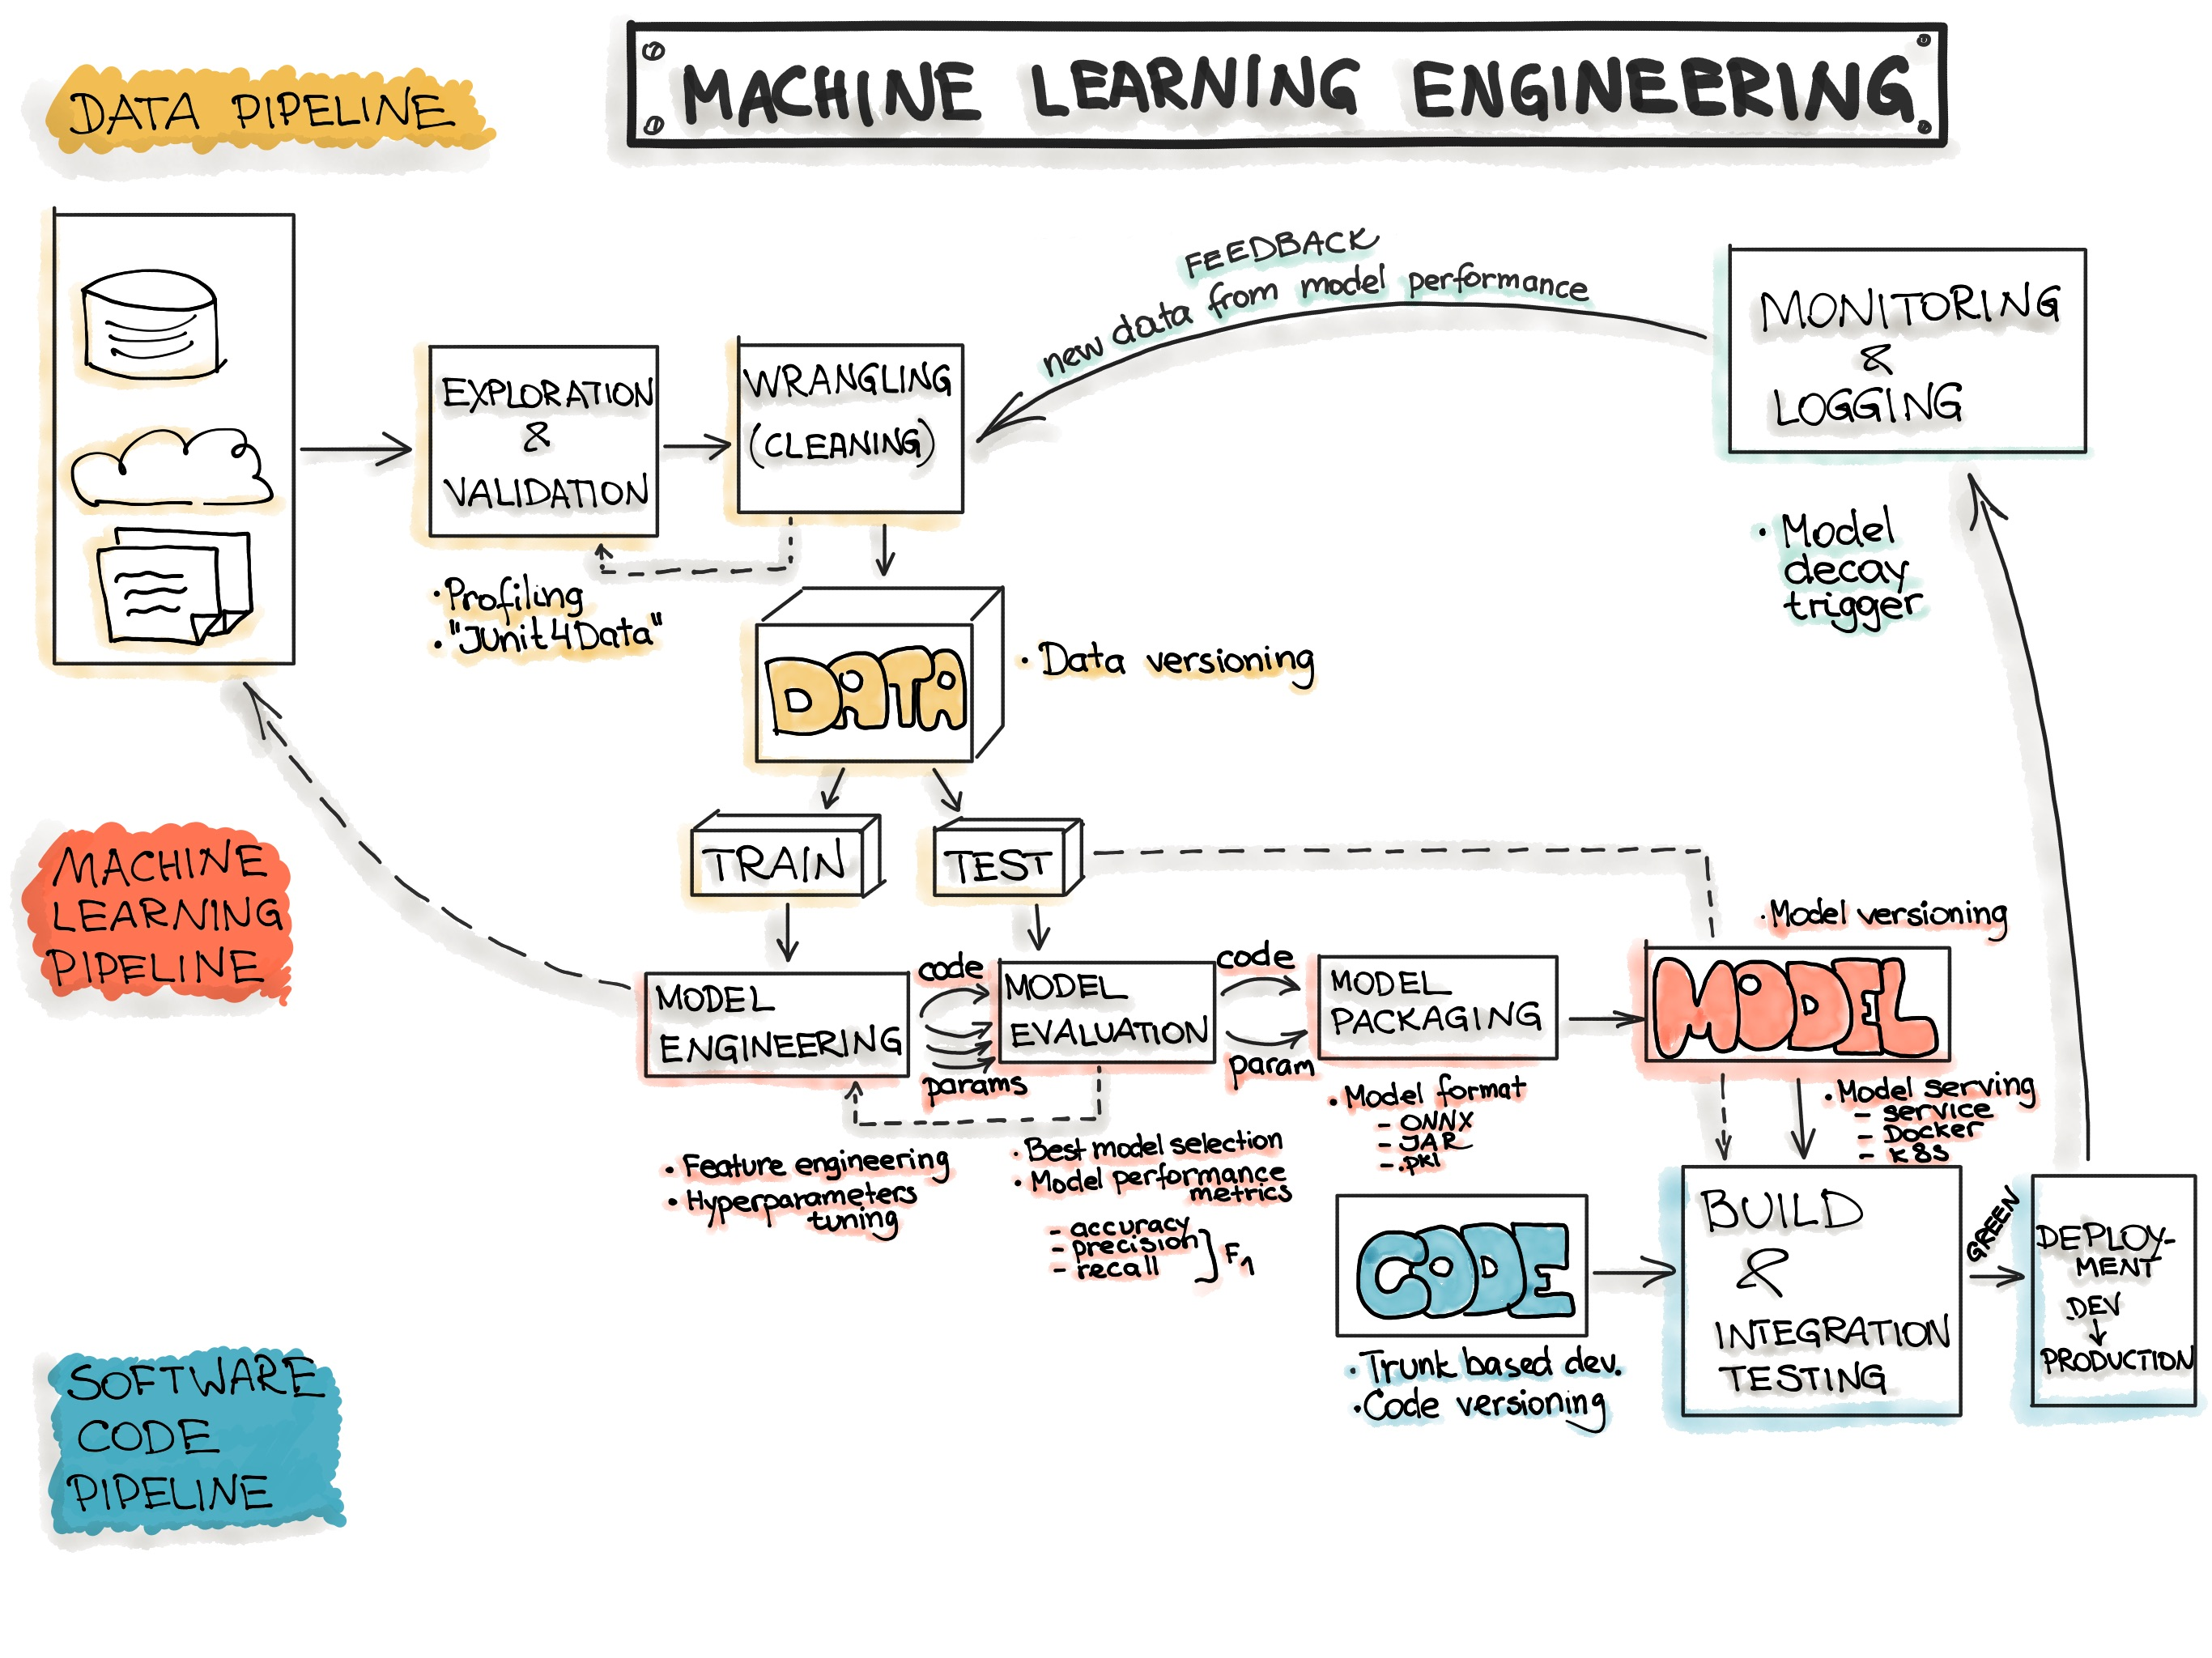

 **Three Main Steps**:

1.   Data Preprocessing
2.   Model Engineering
3.   Model Depolyment

**DATA Preprocessing**



*   Data Gathering/Integration
*   Data Exploration
*   Data Cleaning
*   Data Transforming


**Model Engineering**

*  Model Training
* Model Evaluation
* Model Testing


**Model Deployment**

* Model Serving
* Model Performance monitoring



# **Important Libraries**








**Libraries required for importing data**:

* Pandas


```
import pandas as pd
```



**Libraries required for visualizing data**:

* Matplotlib
* seaborn

```
import matplotlib.pyplot as plt
import seaborn as sns
```

**Libraries required for handling specific data types:**

* Numerical =>  Numpy
* Images =>  OpenCV
* Text =>  NLTK
* Audio =>  Librosa
```
import numpy as np
import cv2
import nltk
import librosa
```

## **Installing Libraries**

If you are using Google Colab, some of the libraries are preinstalled .

If you are using Anaconda, almost all the libraries will be pre installed with the package.

If you have downloaded individual Jupyter notebook you will need to install all the required libraries before importing them into code.

Must ensure that you have pip installed in your systems

In [ ]:
!python3 -m pip --version

pip 24.1.2 from /usr/local/lib/python3.13/dist-packages/pip (python 3.13)


Install the library in Python using the pip command in the command prompt (cmd)

You can also install libraries directly from the jupyter notebook by placing "!" before any command.


```
!pip install package_name
```

For the purpose of this notebook, we need to install all the above mentioned libararies, make sure to install them if they are not already installed.


In [ ]:
!pip3 install pandas matplotlib numpy seaborn --no-deps

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import nltk
import librosa



# **DIFFERENT TYPES OF DATA**


## **Tabular Data**
 * Categorical Labels
 * Numerical Labels


### **Iris Dataset (Categorical Labels)**


The Iris flower data set consists of 150 samples.

**Three species of Iris:**

* Iris setosa
* Iris virginica
* Iris versicolor

**Four features were measured for each sample:**

* Length of the sepals (cm)
* Width of the sepals (cm)
* Length of the petals (cm)
* Width of the petals (cm)

**Problem Statement:**

Distinguish the flowers based on these features.

*Independent variables (Features)*:  
* Length of the sepals
* Length of the petals
* Width of the sepals
* Width of the petals

*Dependent variables (Labels)*:
* Species of the flower



**Importing Required libraries**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#%matplotlib inline

**Loading Dataset**


Download the dataset from : https://www.kaggle.com/datasets/uciml/iris

Copy the path of the dataset and paste it in the command *below*

In [ ]:
dataset_1 = pd.read_csv("/content/drive/MyDrive/Projects/Iris(in).csv")

Preview the dataset

In [ ]:
dataset_1.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
dataset_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


When the data is simply analyzed, none of the 6 columns contain null values, which will be a great advantage. The "Species" column will be the target feature and except for the "Id" column, which can be ignored, the other columns are of type "float64".

In [ ]:
dataset_1.describe(include='all')

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


In the describe method, apart from the parameters that are very useful for numerical features (mean, median, 1Q, 3Q etc.), parameters such as "unique, top, freq" that will be used for categorical features are indicated with "include=all".

In [ ]:
dataset_1['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


The 3 different variables of the target feature are distributed in equal numbers.

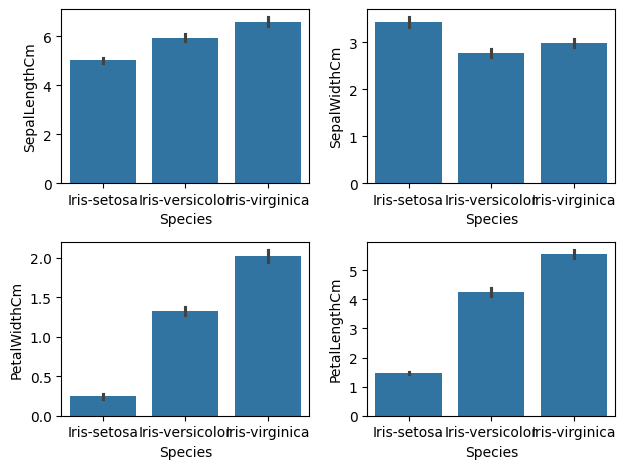

In [ ]:
fig,(ax1,ax2) = plt.subplots(2,2)
sns.barplot(dataset_1,x=dataset_1.Species,y=dataset_1.SepalLengthCm,ax=ax1[0])
sns.barplot(dataset_1,x=dataset_1.Species,y=dataset_1.SepalWidthCm,ax=ax1[1])
sns.barplot(dataset_1,x=dataset_1.Species,y=dataset_1.PetalWidthCm,ax=ax2[0])
sns.barplot(dataset_1,x=dataset_1.Species,y=dataset_1.PetalLengthCm,ax=ax2[1])
plt.tight_layout()
plt.show()

Explore the dataset more from : https://www.kaggle.com/datasets/uciml/iris

### **House Price Prediction (Numerical Labels)**

Consisting of 4600 entries for homes in different US cities, this dataset includes 18 different variables that describe various property details such as size and location characteristics.

**Columns**

* date: Date the house was sold
* price: Sale price of the house (Prediction target)
* bedrooms: Number of the bedrooms
* bathrooms: Number the bathrooms
* sqft_living: Square footage of the home
* sqft_lot: Square footage of the lot
* floors: Total floors (levels) in the house
* waterfront: House which has a view to a waterfront
* view: Number of views
* condition: How good the condition is overall
* sqft_above: Square footage of the house apart from basement
* sqft_basement: Square footage of the basement
* yr_built: Building year of the house
* yr_renovated: Renovation year of the house
* street: Street where the house is located
* city: City where the house is located
* statezip: Zip code of the region where the house is located
* country: Country where the house is located (USA)

There are 8 categorical (half nominal and half ordinal depending on the measurement level) and 9 discrete variables.

Our ordinal variables, waterfront, view and and renovation year, appear numerically, but we will evaluate them in two categories, 0 and 1, depending on whether they are in the relevant house or not. Also, the condition has 5 unique values that increase from 1 to 5 based on the state of the house. And as you might guess, street, city, statezip, and country are the nominal ones.

**Types of Data**

* Categorical (gender, blood type, aswers of yes/no questions, satisfaction/condition level etc.)

* Numerical
    1.   Discrete (finite numbers- # of children/customer/room,physical money, time on a clock etc.)
    2.   Continuous (infinite numbers- measurements(weight, height), time in general etc.)


**Levels of Measurement**

* Qualitative
a. Nominal (Can not be ordered- gender, blood type, seasons)
b. Ordinal (Takes values with an order or rank- satisfaction, condition level)
* Quantitative
a. Interval (Don't have a true zero- temperature, pH, IQ test etc.)
b. Ratios (Have a true zero- temperature only in Kelvin, amount, distance, pulse etc.)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#%matplotlib inline

**Loading Dataset**


Download the dataset from :https://www.kaggle.com/datasets/shree1992/housedata/data
Copy the path of the dataset and paste it in the command *below*


In [ ]:

dataset_2 = pd.read_csv("/content/drive/MyDrive/Projects/HousePricePrediction(in).csv")

dataset_2.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


**Exploring Dataset**

In [ ]:
dataset_2.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
dataset_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

**Handling missing values**

There is no NaN value in our data set, but it would be good to check 0's or 999's for the sake of data consistency. I don't see any irrelevant max values in the describe output but there are some zeros to check.



In [ ]:
dataset_2[dataset_2==0].count()

,0
date,0
price,49
bedrooms,2
bathrooms,2
sqft_living,0
sqft_lot,0
floors,0
waterfront,4567
view,4140
condition,0


We have to deal with 49 houses that look free of cost, plus 2 houses each without a bedroom and a bathroom. Since they are few in number, we can remove these values directly from our data set.




In [ ]:
dataset_2 = dataset_2.drop(dataset_2[(dataset_2['price']==0)].index)
dataset_2 = dataset_2.drop(dataset_2[(dataset_2['bedrooms']==0)].index)
dataset_2 = dataset_2.drop(dataset_2[(dataset_2['bathrooms']==0)].index)

In [ ]:
dataset_2.shape

(4549, 18)

We can see now 4549 samples are left after removing samples with missing data. We can further explore the data and find outliers.

For further exploration see: https://www.kaggle.com/datasets/shree1992/housedata

## **Text Data**




The data is basically a collection of tweets annotated with the emotions behind them. We have three columns tweet_id, sentiment, and content. In "content" we have the raw tweet. In "sentiment" we have the emotion behind the tweet. Refer to the starter notebook for more insights.

The data has 13 different emotion 40000 records.

**Problem**: Finding the emotion for each tweet, also called emotion recognition from Text.

Importing required Libraries

In [ ]:
import pandas as pd
import seaborn as sns

import re
import nltk
import nltk
from nltk.corpus import stopwords

from nltk.stem.snowball import SnowballStemmer
from wordcloud import WordCloud

Download the dataset from: https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text/data


Loading Dataset

In [ ]:
dataset_3 = pd.read_csv("/content/drive/MyDrive/Projects/tweet_emotions(in).csv")
dataset_3.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


Dimensions of the data  : 40,000 samples, with 3 columns

In [ ]:
dataset_3.shape

(40000, 3)

Data Cleaning and EDA

In [ ]:
dataset_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   content    40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


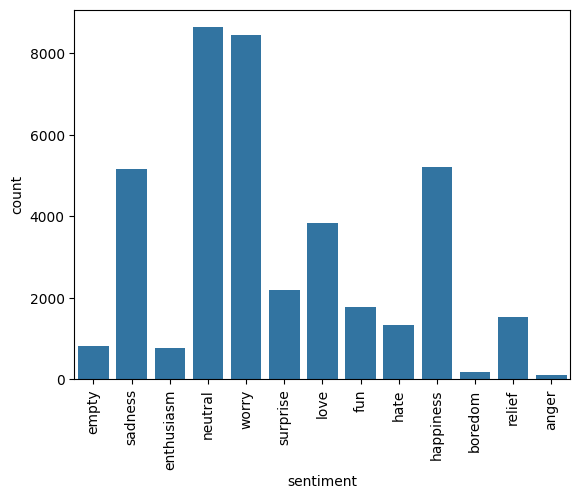

In [ ]:
sns.countplot(x=dataset_3['sentiment'])
plt.xticks(rotation=90)
plt.show()

Text Preprocessing

In [ ]:
import ssl
import nltk

# Force Python to bypass the SSL certificate verification check
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Now run the download
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')

In [ ]:
def clean(text):
    text = text.lower()
    text = re.sub('[^\w\s]', '', text)
    text = [word for word in text.split() if word not in stop_words]
    text = [stemmer.stem(w) for w in text]
    return text

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1444/3999034638.py:3: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('[^\w\s]', '', text)


In [ ]:
dataset_3['text'] = dataset_3['content'].apply(lambda x: clean(x))
dataset_3['text'] = dataset_3['text'].apply(lambda x: ' '.join(x))
dataset_3.head()

,tweet_id,sentiment,content,text
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...,tiffanylu know listenin bad habit earlier star...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...,layin n bed headach ughhhhwaitin call
2,1956967696,sadness,Funeral ceremony...gloomy friday...,funer ceremonygloomi friday
3,1956967789,enthusiasm,wants to hang out with friends SOON!,want hang friend soon
4,1956968416,neutral,@dannycastillo We want to trade with someone w...,dannycastillo want trade someon houston ticket...


Word Cloud

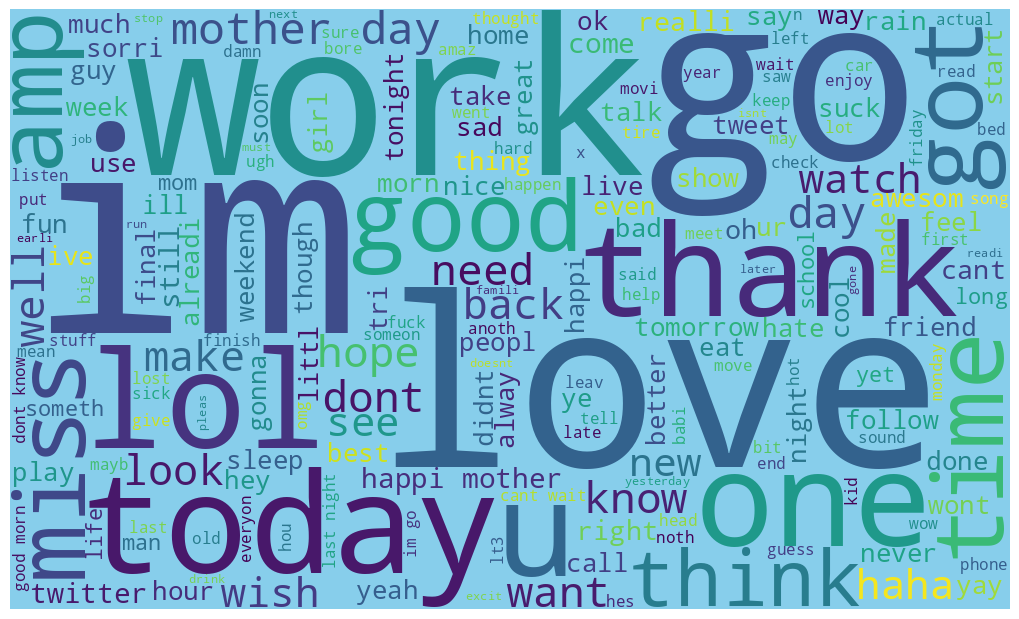

In [ ]:
all_words = ' '.join(word for word in dataset_3['text'])


wordcloud = WordCloud(
    width = 1000,
    height = 600,
    background_color = 'skyblue',
    min_font_size = 10).generate(all_words)
plt.figure(figsize = (10, 6), facecolor = None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

## **Images Data**


 Download the data from : https://www.kaggle.com/datasets/saworz/human-faces-with-labels/data


There are two folders:
1. **Data**
     
      Contains images of faces
2. **Labels**
      
      Contains bounding boxes (labels) for the images




Importing required Libraries

In [ ]:
from pathlib import Path
import os
from os import listdir
from os.path import isfile, join
import random as random
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches


Get Data from folders

In [ ]:
data_path= "/content/drive/MyDrive/Projects/Data"
images_path = "/content/drive/MyDrive/Projects/Data/Images"
annotations_path="/content/drive/MyDrive/Projects/Data/Labels"


Directory Exploration

In [ ]:

def walk_through_dir(dir_path: Path) -> None:
    """Prints dir_path content"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} folders and {len(filenames)} files in '{dirpath}' folder ")


walk_through_dir(data_path)


There are 2 folders and 0 files in '/content/drive/MyDrive/Projects/Data' folder 
There are 0 folders and 169 files in '/content/drive/MyDrive/Projects/Data/Images' folder 
There are 0 folders and 606 files in '/content/drive/MyDrive/Projects/Data/Labels' folder 


Print some random images and draw bounding boxes to see if they are correct

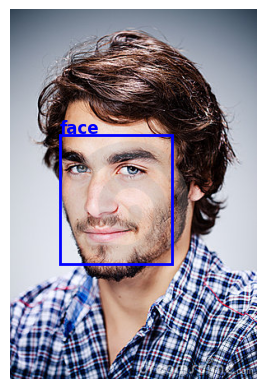

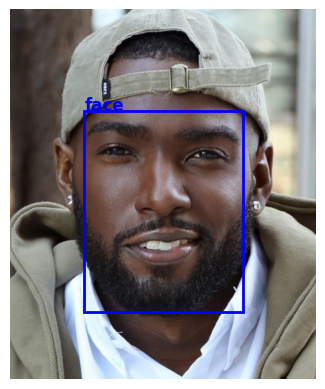

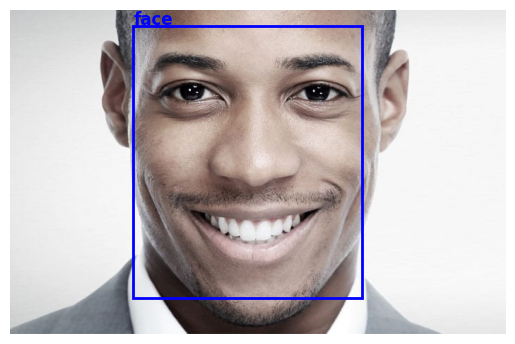

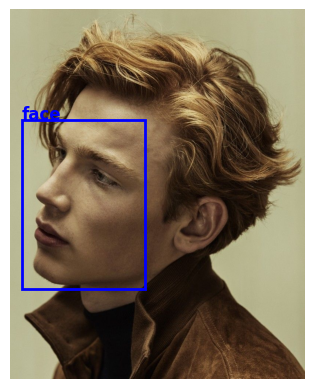

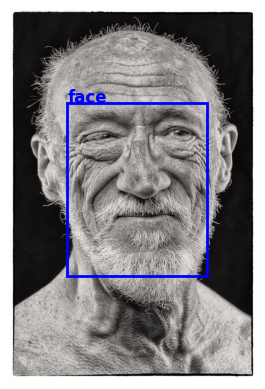

In [ ]:

def print_random_images(photos: list, n: int = 5, seed=None):
    if n > 10:
        n=10
    if seed:
        rnd.seed(seed)

    for im in range(n):
        random_photo = random.choice(photos)
        random_photo_path = str(images_path) + '/' + str(random_photo)

        with Image.open(random_photo_path) as fd:
            fig, ax = plt.subplots()
            ax.imshow(fd)
            ax.axis(False)
            image_width, image_height = fd.size

        file=random_photo[:random_photo.index(".")] + '.txt'
        annotation_file = annotations_path+"/"+ file
        with open(annotation_file) as f:
            label = f.read()

        labels = label.split(" ")
        labels[4] = labels[4][:-1]
        labels = list(map(float, labels))

        x1, y1, width, height=labels[1:]
        bbox_x = x1*image_width-image_width*width/2
        bbox_y = y1*image_height-image_height*height/2
        bbox_width=width*image_width
        bbox_height=height*image_height

        mpatch=mpatches.Rectangle((bbox_x, bbox_y), bbox_width, bbox_height, linewidth=1, edgecolor='b', facecolor="none", lw=2)
        ax.add_patch(mpatch)
        rx, ry = mpatch.get_xy()
        ax.annotate('face', (rx, ry-2), color='blue', weight='bold', fontsize=12, ha='left', va='baseline')

photos_list = [f for f in listdir(images_path) if isfile(join(images_path, f))]

print_random_images(photos_list)

## **Audio Data**


**Files**
This portion of the RAVDESS contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

**File naming convention**

Each of the 1440 files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav). These identifiers define the stimulus characteristics:

**Filename identifiers**

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).

* Vocal channel (01 = speech, 02 = song).

* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).

* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.

* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").

* Repetition (01 = 1st repetition, 02 = 2nd repetition).

* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: 03-01-06-01-02-01-12.wav

1. Audio-only (03)
2. Speech (01)
3. Fearful (06)
4. Normal intensity (01)
5. Statement "dogs" (02)
6. 1st Repetition (01)
7. 12th Actor (12) Female, as the actor ID number is even.


Importing Libraries

In [4]:
#importing the required libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa.display
import soundfile
import os

from glob import glob

import librosa
import IPython.display as ipd

Download the dataset from the [audio dataset folder.](https://1sfu-my.sharepoint.com/:f:/g/personal/oyalcin_sfu_ca/ErKIxg5g4rFOlfrAZ352DW4BD1ytBiz1kZLcj5Elk9_1rQ?e=lgUQoi)

### Load the Dataset and Compute Features
We have to understand the labelling of the RAVDESS dataset to find the ground truth emotion for each sample.
Each file is labelled with 7 numbers delimited by a "-".
Most of the numbers describe metadata about the audio samples such as their format (video and/or audio),
whether the audio is a song or statement, which of two statements is being read and by which actor.

The third and fourth numbers pertain to the emotional quality of each sample. The third number is in the range of 1-8 with each number representing an emotion.
The fourth number is either 1 or 2, representing normal (1) or strong (2) emotional intensity.

When you upload your own data, you should be using this convention.

We're going to define a dictionary based on the third number (emotion) and assign an emotion to each number as specified by the RAVDESS dataset:

In [2]:
Dataset_audio="/content/drive/MyDrive/Projects/Audio Data"

In [20]:
# Look inside your mounted Google Drive instead
audio_files =glob.glob('/content/drive/MyDrive/Projects/Audio Data/*/*.wav')

# Play the first file
ipd.Audio(audio_files[0])

In [17]:
#Emotions in the RAVDESS dataset
emotions_dict ={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

Now we're going to load our data and extract the emotion names according to the list we provided above.

In [21]:
import os, glob
def load_data():
    X, y = [], []
    count = 0

    # FIX: Added '/*.wav' so glob finds the actual audio files inside the folder
    audio_pattern = "/content/drive/MyDrive/Projects/Audio Data/*/*.wav"

    for file in glob.glob(audio_pattern):
        file_name = os.path.basename(file)

        # Parse the emotion code from the RAVDESS style filename (e.g., 03-01-03-...)
        emotion = emotions_dict[file_name.split("-")[2]]

        # features = get_features(file)
        # X.append(features)
        y.append(emotion)
        count += 1
        print('\r' + f' Processed {count} audio samples', end=' ')

    print(f"\nTotal labels processed: {len(y)}")
    return np.array(X), np.array(y)

# Call the function to populate your arrays
X, emotions = load_data()

 Processed 376 audio samples 
Total labels processed: 376


We will not compute the feature matrix this week, but we will read the emotion labels for the entire dataset.
We will explain why the X and Y elements are important in the upcoming weeks.

In [13]:
features, emotions = load_data()


Total labels processed: 0


Let's now see the class balance of our dataset, it is important to have a balanced dataset for ML models.

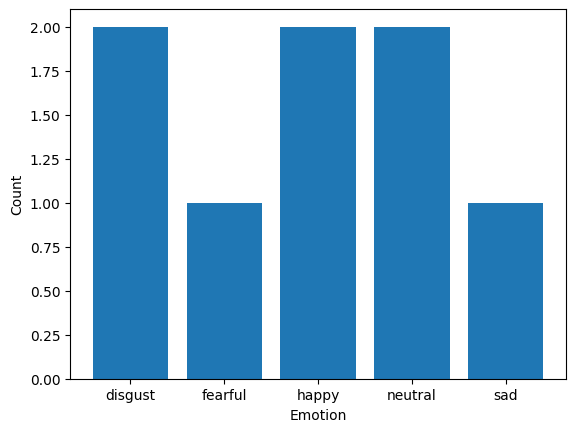

In [27]:
emotion_list, count = np.unique(emotions, return_counts=True)

# Check if we actually have data before plotting
if len(emotion_list) == 0:
    print("❌ Error: The 'emotions' variable is empty! Check how you loaded your dataset.")
else:
    # Use len(emotion_list) instead of a hardcoded 8 to prevent shape mismatches
    plt.bar(x=range(len(emotion_list)), height=count)
    plt.xticks(ticks=range(len(emotion_list)), labels=[emotion for emotion in emotion_list], fontsize=10)
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.show()

**Great, the classes appear to be balanced. That makes the task easier.** All emotions _except_ the neutral class have a "strong" intensity so there are half as many neutral samples. That might have an impact.

We will continue working on this dataset in the upcoming weeks, so save your work!

In [10]:
male_count = 0
female_count = 0
nb_count = 0

audio_pattern = "/content/drive/MyDrive/Projects/Audio Data/*/*.wav"

for file in glob(audio_pattern):
    file_name = os.path.basename(file)
    parts = file_name.split(".")[0].split("-")

    if len(parts) >= 7:
        actor_identifier = parts[6] # 7th identifier is the Actor ID

        # Check if the identifier is purely numbers
        if actor_identifier.isdigit():
            actor_code = int(actor_identifier)
            if actor_code % 2 != 0:
                male_count += 1
            else:
                female_count += 1
        else:
            # If it contains letters or non-numeric characters, group as NB
            nb_count += 1

print(f"Total Male Samples: {male_count}")
print(f"Total Female Samples: {female_count}")
print(f"Total NB Samples: {nb_count}")

Total Male Samples: 196
Total Female Samples: 180
Total NB Samples: 0


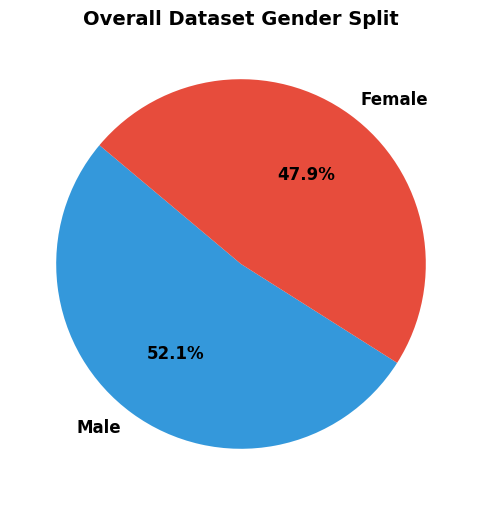

In [11]:
# Data to plot
labels = ['Male', 'Female', 'NB']
sizes = [male_count, female_count, nb_count]
colors = ['#3498db', '#e74c3c', '#9b59b6'] # Blue, Coral, and Purple for NB

# Filter out categories that have 0 samples so the chart labels look clean
plot_labels = [l for l, s in zip(labels, sizes) if s > 0]
plot_sizes = [s for s in sizes if s > 0]
plot_colors = [c for c, s in zip(colors, sizes) if s > 0]

plt.figure(figsize=(6, 6))
plt.pie(
    plot_sizes,
    labels=plot_labels,
    colors=plot_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title("Overall Dataset Gender Split", fontsize=14, fontweight='bold')
plt.show()

In [25]:
# Look inside your mounted Google Drive instead
audio_files =glob.glob('/content/drive/MyDrive/Projects/Ash-Audio/*.wav')

# Play the first file
ipd.Audio(audio_files[3])

In [26]:
import os, glob
def load_data():
    X, y = [], []
    count = 0

    # FIX: Added '/*.wav' so glob finds the actual audio files inside the folder
    audio_pattern = "/content/drive/MyDrive/Projects/Ash-Audio/*.wav"

    for file in glob.glob(audio_pattern):
        file_name = os.path.basename(file)

        # Parse the emotion code from the RAVDESS style filename (e.g., 03-01-03-...)
        emotion = emotions_dict[file_name.split("-")[2]]

        # features = get_features(file)
        # X.append(features)
        y.append(emotion)
        count += 1
        print('\r' + f' Processed {count} audio samples', end=' ')

    print(f"\nTotal labels processed: {len(y)}")
    return np.array(X), np.array(y)

# Call the function to populate your arrays
X, emotions = load_data()

 Processed 8 audio samples 
Total labels processed: 8


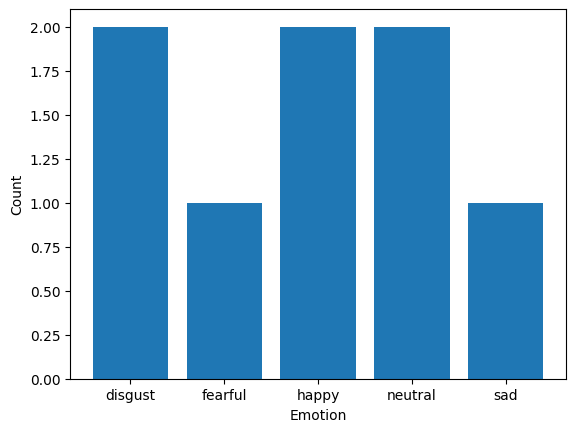

In [28]:
emotion_list, count = np.unique(emotions, return_counts=True)

# Check if we actually have data before plotting
if len(emotion_list) == 0:
    print("❌ Error: The 'emotions' variable is empty! Check how you loaded your dataset.")
else:
    # Use len(emotion_list) instead of a hardcoded 8 to prevent shape mismatches
    plt.bar(x=range(len(emotion_list)), height=count)
    plt.xticks(ticks=range(len(emotion_list)), labels=[emotion for emotion in emotion_list], fontsize=10)
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.show()

In [30]:
male_count = 0
female_count = 0
nb_count = 0

audio_pattern = "/content/drive/MyDrive/Projects/Ash-Audio/*.wav"

for file in glob.glob(audio_pattern):
    file_name = os.path.basename(file)
    parts = file_name.split(".")[0].split("-")

    if len(parts) >= 7:
        actor_identifier = parts[6] # 7th identifier is the Actor ID

        # Check if the identifier is purely numbers
        if actor_identifier.isdigit():
            actor_code = int(actor_identifier)
            if actor_code % 2 != 0:
                male_count += 1
            else:
                female_count += 1
        else:
            # If it contains letters or non-numeric characters, group as NB
            nb_count += 1

print(f"Total Male Samples: {male_count}")
print(f"Total Female Samples: {female_count}")
print(f"Total NB Samples: {nb_count}")

Total Male Samples: 0
Total Female Samples: 0
Total NB Samples: 8


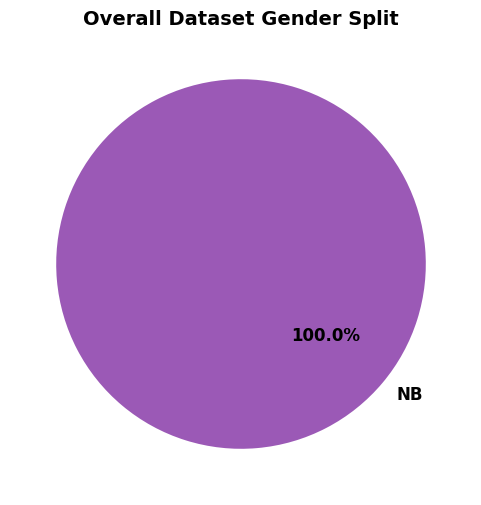

In [31]:
# Data to plot
labels = ['Male', 'Female', 'NB']
sizes = [male_count, female_count, nb_count]
colors = ['#3498db', '#e74c3c', '#9b59b6'] # Blue, Coral, and Purple for NB

# Filter out categories that have 0 samples so the chart labels look clean
plot_labels = [l for l, s in zip(labels, sizes) if s > 0]
plot_sizes = [s for s in sizes if s > 0]
plot_colors = [c for c, s in zip(colors, sizes) if s > 0]

plt.figure(figsize=(6, 6))
plt.pie(
    plot_sizes,
    labels=plot_labels,
    colors=plot_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title("Overall Dataset Gender Split", fontsize=14, fontweight='bold')
plt.show()

 Processed 384 audio samples 
Total labels processed: 384


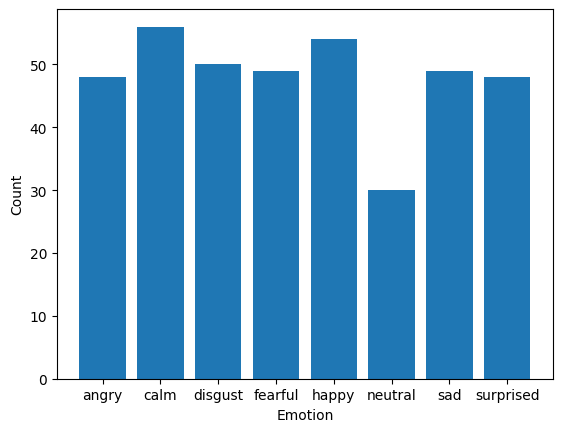

In [33]:
import os, glob
def load_data():
    X, y = [], []
    count = 0

    # FIX: Added '/*.wav' so glob finds the actual audio files inside the folder
    audio_pattern = "/content/drive/MyDrive/Projects/Ash-Audio/*.wav"

    for file in glob.glob(audio_pattern):
        file_name = os.path.basename(file)

        # Parse the emotion code from the RAVDESS style filename (e.g., 03-01-03-...)
        emotion = emotions_dict[file_name.split("-")[2]]

        # features = get_features(file)
        # X.append(features)
        y.append(emotion)
        count += 1
    audio_pattern = "/content/drive/MyDrive/Projects/Audio Data/*/*.wav"

    for file in glob.glob(audio_pattern):
        file_name = os.path.basename(file)

        # Parse the emotion code from the RAVDESS style filename (e.g., 03-01-03-...)
        emotion = emotions_dict[file_name.split("-")[2]]

        # features = get_features(file)
        # X.append(features)
        y.append(emotion)
        count += 1
        print('\r' + f' Processed {count} audio samples', end=' ')


        print('\r' + f' Processed {count} audio samples', end=' ')

    print(f"\nTotal labels processed: {len(y)}")
    return np.array(X), np.array(y)

# Call the function to populate your arrays
X, emotions = load_data()

emotion_list, count = np.unique(emotions, return_counts=True)

# Check if we actually have data before plotting
if len(emotion_list) == 0:
    print("❌ Error: The 'emotions' variable is empty! Check how you loaded your dataset.")
else:
    # Use len(emotion_list) instead of a hardcoded 8 to prevent shape mismatches
    plt.bar(x=range(len(emotion_list)), height=count)
    plt.xticks(ticks=range(len(emotion_list)), labels=[emotion for emotion in emotion_list], fontsize=10)
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.show()

In [35]:
male_count = 0
female_count = 0
nb_count = 0

audio_pattern = "/content/drive/MyDrive/Projects/Audio Data/*/*.wav"

for file in glob.glob(audio_pattern):
    file_name = os.path.basename(file)
    parts = file_name.split(".")[0].split("-")

    if len(parts) >= 7:
        actor_identifier = parts[6] # 7th identifier is the Actor ID

        # Check if the identifier is purely numbers
        if actor_identifier.isdigit():
            actor_code = int(actor_identifier)
            if actor_code % 2 != 0:
                male_count += 1
            else:
                female_count += 1
        else:
            # If it contains letters or non-numeric characters, group as NB
            nb_count += 1
audio_pattern = "/content/drive/MyDrive/Projects/Ash-Audio/*.wav"

for file in glob.glob(audio_pattern):
    file_name = os.path.basename(file)
    parts = file_name.split(".")[0].split("-")

    if len(parts) >= 7:
        actor_identifier = parts[6] # 7th identifier is the Actor ID

        # Check if the identifier is purely numbers
        if actor_identifier.isdigit():
            actor_code = int(actor_identifier)
            if actor_code % 2 != 0:
                male_count += 1
            else:
                female_count += 1
        else:
            # If it contains letters or non-numeric characters, group as NB
            nb_count += 1

print(f"Total Male Samples: {male_count}")
print(f"Total Female Samples: {female_count}")
print(f"Total NB Samples: {nb_count}")

Total Male Samples: 196
Total Female Samples: 180
Total NB Samples: 8


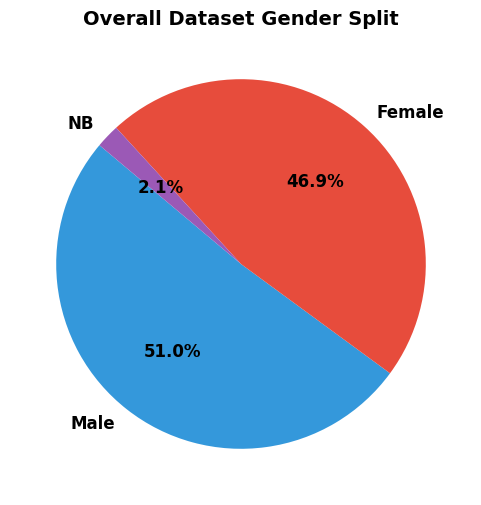

In [36]:
# Data to plot
labels = ['Male', 'Female', 'NB']
sizes = [male_count, female_count, nb_count]
colors = ['#3498db', '#e74c3c', '#9b59b6'] # Blue, Coral, and Purple for NB

# Filter out categories that have 0 samples so the chart labels look clean
plot_labels = [l for l, s in zip(labels, sizes) if s > 0]
plot_sizes = [s for s in sizes if s > 0]
plot_colors = [c for c, s in zip(colors, sizes) if s > 0]

plt.figure(figsize=(6, 6))
plt.pie(
    plot_sizes,
    labels=plot_labels,
    colors=plot_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title("Overall Dataset Gender Split", fontsize=14, fontweight='bold')
plt.show()